In [1]:
# importing librarries
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# import dataset
words = open("names.txt", 'r').read().splitlines()
words[:4]

['emma', 'olivia', 'ava', 'isabella']

In [3]:
len(words)

32033

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1]) # training set: 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # validation set : 10%
Xte, Yte = build_dataset(words[n2:]) # test set : 10%


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# mlp
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g) 
# the setting of scaling factor is very important (mostly because we are only using gradient descent, and not using any fancy optimizer like Adam or RMSProp)
# the best way proposed in the paper mentioned and torch docs is 
# to multiply the weights by (5/3)/ (fan_in)**0.5, where fan_in in our case is block_size * n_embd, and the factor 5/3 is a magic number that works well in practice.
W1 = torch.randn((block_size * n_embd, n_hidden), generator = g) * (5/3) /( (block_size * n_embd)**0.5) #* 0.2
# the above thing is done to get the standard deviation of the weights to be 1, which is a good practice for training neural networks, and also to make sure that the weights are not too large, which can cause the gradients to explode and the training to diverge.
# the above methodology is not very much used today, due to the use of optimizers and normalization techniques like batch normalization
# b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch normalization parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [254]:
# Creating a pytorch like api
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
    # the momentum parameter as 0.1 was too high and was causing the variance to explode, and made the running variance inf
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum = 0.01):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters trained with backprop
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)# , unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x-xmean)/ torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, n_hidden, bias=False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden, vocab_size, bias=False),BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # last layer: make less confident (not too peaky) at the start of training, so that the gradients are not too small
    # layers[-1].weight *= 0.1 
    layers[-1].gamma *= 0.1 # since the last layer is now batchnorm, we can just scale the gamma parameter instead of scaling the weights directly
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


47024


In [255]:
# hpreact.shape

In [256]:
# hpreact.mean(0, keepdim=True).shape

In [257]:

# hpreact.std(0, keepdim=True).shape

In [258]:
max_steps = 200000
batch_size = 32
lossi = []
ud =[]

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    # embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # this is using the new pytorch like api
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
    # linear layer
    # since we are subtracting the mean from hpreact, the bias term is not needed, as it will just be subtracted through the mean.
    # hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
   
    # Batch Normalization
    # we want to have stand deviation of this similar to gaussian, but only during initialization. 
    # therefore we use bngain and bnbias to scale and shift the practivation
    # and since they are initialized with ones, therefore it makes allows the batch deviation similar to guassion
    # later since bngain and bnbias are learnable parameters, they will be updated during training to make the hidden layer pre-activation more suitable for the task at hand.
    # bnmeani = hpreact.mean(0, keepdim=True)
    # bnstdi = hpreact.std(0, keepdim=True)
    # hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias # normalize the hidden layer pre-activation

    # when we are inferencing, we cannot use the batch statistics to calc mean and std, because we are not using a batch, 
    # therefore we use the running mean and std to normalize the hidden layer pre-activation
    # with torch.no_grad():
    #     bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    #     bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # nonlinear layer
    # h = torch.tanh(hpreact) # hidden layer
    # logits = h @ W2 + b2 # output layer
    # loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # retain the gradient of the output of each layer for debugging
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    lr = 0.1  # after checking the weight update ratio graph, the above method of step learning was a failure 
    for p in parameters:
        p.data += -lr * p.grad

    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    # if i > 1000:
    #     break

      0/ 200000: 3.2870
  10000/ 200000: 2.3273
  20000/ 200000: 2.1019
  30000/ 200000: 1.9020
  40000/ 200000: 2.1643
  50000/ 200000: 2.1520
  60000/ 200000: 1.7767
  70000/ 200000: 2.1514
  80000/ 200000: 2.3802
  90000/ 200000: 1.9338
 100000/ 200000: 2.3943
 110000/ 200000: 2.1508
 120000/ 200000: 2.1813
 130000/ 200000: 2.0889
 140000/ 200000: 1.8096
 150000/ 200000: 1.9132
 160000/ 200000: 2.0349
 170000/ 200000: 1.9936
 180000/ 200000: 2.2985
 190000/ 200000: 1.9573


Implemented a couple of visualizations to monitor the training process.

layer 2 (      Tanh): mean +0.01, std 0.71, saturated 18.00%
layer 5 (      Tanh): mean -0.02, std 0.76, saturated 22.84%
layer 8 (      Tanh): mean +0.01, std 0.79, saturated 23.88%
layer 11 (      Tanh): mean +0.00, std 0.80, saturated 26.94%
layer 14 (      Tanh): mean +0.02, std 0.82, saturated 28.03%


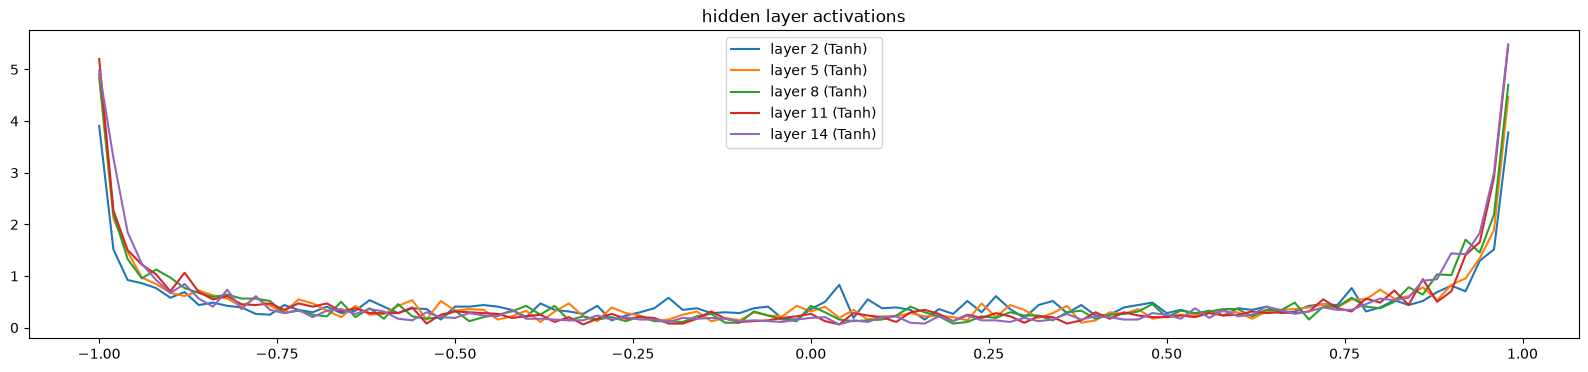

In [259]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %0.2f, saturated %0.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx  = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.title("hidden layer activations")
plt.legend(legends)

layer 2 (      Tanh): mean -0.000000, std 3.327455e-03 
layer 5 (      Tanh): mean -0.000000, std 3.079390e-03 
layer 8 (      Tanh): mean -0.000000, std 3.191059e-03 
layer 11 (      Tanh): mean +0.000000, std 2.870457e-03 
layer 14 (      Tanh): mean -0.000000, std 3.377852e-03 


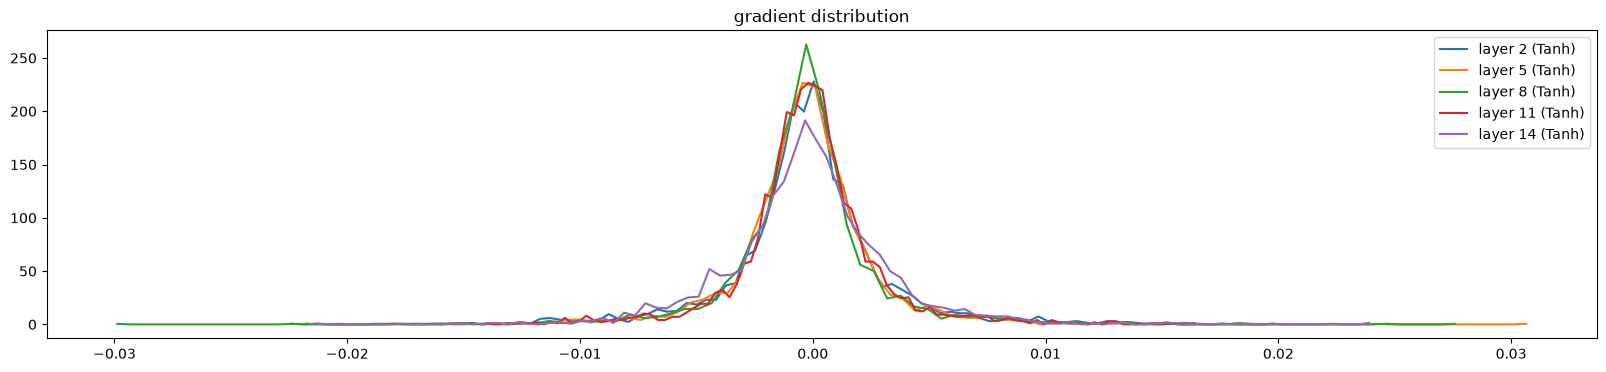

In [260]:
plt.figure(figsize=(20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print("layer %d (%10s): mean %+f, std %e " % (i, layer.__class__.__name__, t.mean(), t.std()  ))
        hy,hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
    plt.legend(legends)
    plt.title("gradient distribution")

weight   (27, 10) | mean -0.000000 | std 1.620044e-02 | grad:data ratio 1.363818e-02
weight  (30, 100) | mean -0.000103 | std 7.429273e-03 | grad:data ratio 1.683619e-02
weight (100, 100) | mean +0.000056 | std 4.524350e-03 | grad:data ratio 1.683878e-02
weight (100, 100) | mean -0.000000 | std 4.336495e-03 | grad:data ratio 1.631682e-02
weight (100, 100) | mean +0.000063 | std 4.356230e-03 | grad:data ratio 1.715416e-02
weight (100, 100) | mean -0.000003 | std 4.179747e-03 | grad:data ratio 1.763531e-02
weight  (100, 27) | mean -0.000090 | std 6.675826e-03 | grad:data ratio 1.708346e-02


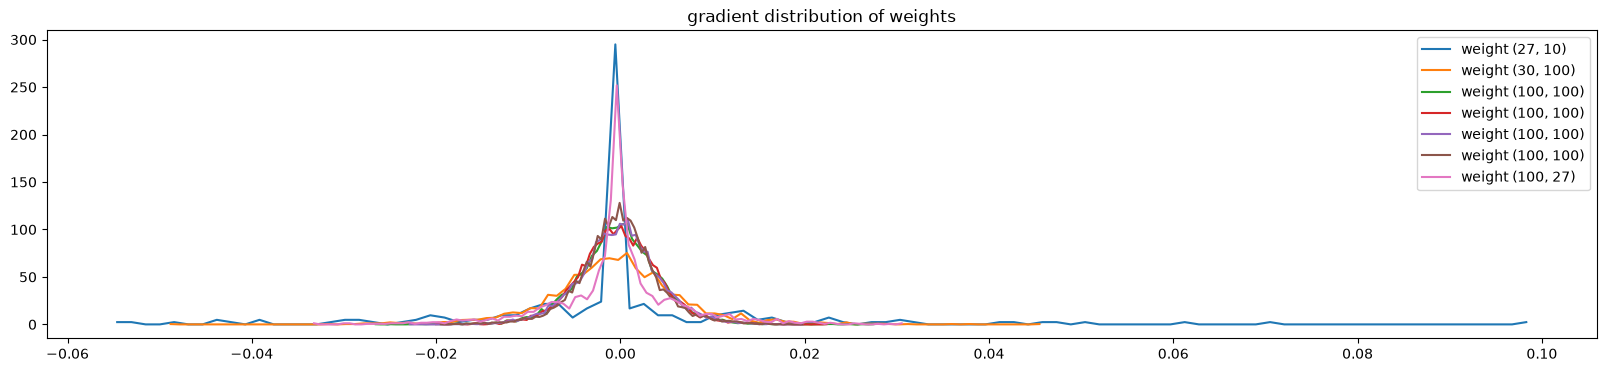

In [261]:
plt.figure(figsize=(20,4))
legends= []
for i,p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'weight {tuple(p.shape)}')
plt.title("gradient distribution of weights")
plt.legend(legends)

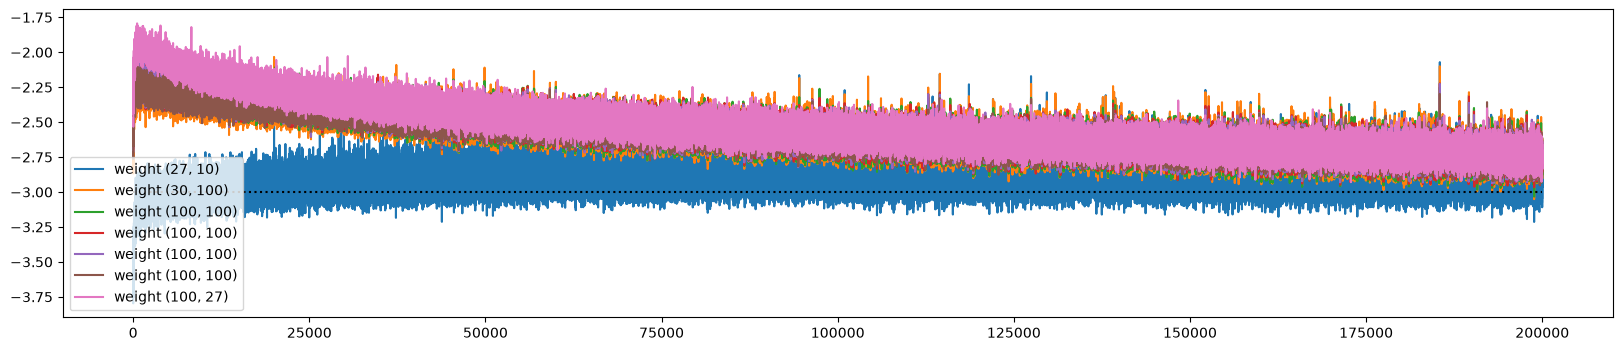

In [262]:
plt.figure(figsize=(20,4))
legends= []
for i,p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'weight {tuple(p.shape)}')
plt.plot([0, len(ud)], [-3, -3], 'k:')
plt.legend(legends)

In [235]:
# if we don't use running mean and std,
# this is how we do it after training, but we dont want to do an extra step
# therefore running mean and std are prefered to be used during training itself, so that we can use them during inference as well.
# with torch.no_grad():
#     emb = C[Xtr] # embed the characters into vectors
#     embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
#     hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
#     # finding mean and std of the hidden layer pre-activation, of the whole training set and not just the batch.
#     bnmean = hpreact.mean(0, keepdim=True)
#     bnstd = hpreact.std(0, keepdim=True)

In [236]:
# h

In [237]:

# plt.hist(h.view(-1).tolist(), bins=50);
# if you see here, most of the values here are saturated at -1 or 1, which is not good. 
# and why is that? this is because during backpropagation, the diff function of tanh is (1 - tanh^2)tanh,
# and since most of our values are -1 or 1, the gradient will be zero and the neuron will not learn anything. This is called the vanishing gradient problem.
# this neuron never learns,  and is a dead neuron.

In [238]:
# plt.hist(hpreact.view(-1).tolist(), bins=50);
# the initial values are very large, and this is a problem.
# in real world training, the initial values are really important, and if they are too large, the neurons will saturate and the gradients will vanish. This is called the vanishing gradient problem.
# we scale the weights down in the initialization to avoid this problem.

In [239]:
# plt.figure(figsize=(20,10))
# plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [240]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

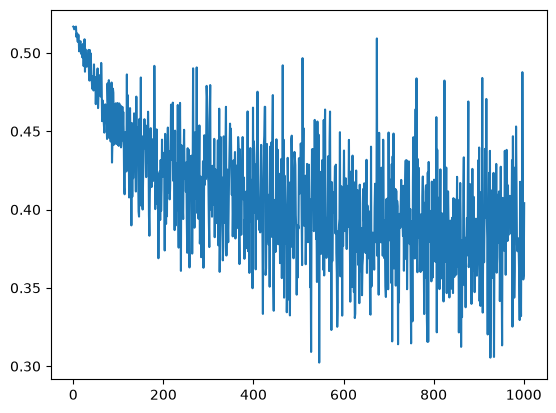

In [247]:
plt.plot(lossi)

In [263]:
@torch.no_grad() # this block does not need gradients
def split_loss(split):
    X, Y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[X] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Y) # loss function

    # hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # normalize the hidden layer pre-activation
    # hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # normalize the hidden layer pre-activation
    # h = torch.tanh(hpreact) # hidden layer
    # logits = h @ W2 + b2 # output layer
    # loss = F.cross_entropy(logits, Y) # loss function
    print(f'{split}: {loss.item():.4f}')

split_loss('train')
split_loss('val')

train: 2.0216
val: 2.0935


In [243]:
# if isinstance(layers[1], BatchNorm1d):
    # print(layers[1])

In [264]:
# sample from the model
g = torch.Generator().manual_seed(2147483647) # for reproducibility
problist = []
for layer in layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False # we are inferencing, so we don't want to update the running mean and std
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])] # embed the characters into vectors
        x= emb.view(emb.shape[0], -1) # concatenate the vectors
        
        for layer in layers:
            # if isinstance(layer, BatchNorm1d):
            #     layer.training = False # we are inferencing, so we don't want to update the running mean and std
            x = layer(x)
        logits = x
        # hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
        
        # sincce we are inferencing, we cannot use the batch statistics to calc mean and std, because we are not using a batch, 
        # therefore we use the running mean and std to normalize the hidden layer pre-activation
        # hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias # normalize the hidden layer pre-activation
        # h = torch.tanh(hpreact) # hidden layer
        # logits = h @ W2 + b2 # output layer
        probs = F.softmax(logits, dim=1) # softmax to get probabilities
        # problist.append(probs[0].tolist())
        # plt.figure(figsize=(20,4))
        # plt.bar(range(vocab_size), probs[0].tolist())
        # plt.title("probability distribution of next character")
        # plt.show()
        # break
        # print(probs.shape)
        # break
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample from the distribution
        context = context[1:] + [ix] # crop and append
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

# plt.figure(figsize=(20,4))
# plt.bar(range(vocab_size), problist[-1])
# plt.title("probability distribution of next character")
# plt.show()

dex
mariah
makima
kayda
kalissana
noluwan
katha
samiyah
javar
gotti
molie
kavo
keyreda
kaley
maside
enkavion
zakls
malynn
broah
ash
